In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/CNN_VGG/

/content/drive/MyDrive/CNN_VGG


In [ ]:
pip install tensorflow-gpu==2.0.0

     |████████████████████████████████| 380.8MB 48kB/s 
     |████████████████████████████████| 51kB 8.2MB/s 
     |████████████████████████████████| 3.8MB 55.4MB/s 
     |████████████████████████████████| 450kB 52.6MB/s 
  Created wheel for gast: filename=gast-0.2.2-cp37-none-any.whl size=7540 sha256=50e0f8a8cac6e6cd7091fac963fc8b47b7e837fae7ebf1db4b591f2f413b52a5
  Stored in directory: /root/.cache/pip/wheels/5c/2e/7e/a1d4d4fcebe6c381f378ce7743a3ced3699feb89bcfbdadadd
Successfully built gast
ERROR: tensorflow 2.4.1 has requirement gast==0.3.3, but you'll have gast 0.2.2 which is incompatible.
ERROR: tensorflow 2.4.1 has requirement numpy~=1.19.2, but you'll have numpy 1.18.5 which is incompatible.
ERROR: tensorflow 2.4.1 has requirement tensorboard~=2.4, but you'll have tensorboard 2.0.2 which is incompatible.
ERROR: tensorflow 2.4.1 has requirement tensorflow-estimator<2.5.0,>=2.4.0, but you'll have tensorflow-estimator 2.0.1 which is incompatible.
ERROR: tensorflow-probability 0.12

In [ ]:
pip show tensorflow

Name: tensorflow
Version: 2.4.1
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.7/dist-packages
Requires: flatbuffers, h5py, protobuf, wheel, google-pasta, keras-preprocessing, six, numpy, gast, grpcio, termcolor, wrapt, absl-py, opt-einsum, astunparse, tensorflow-estimator, typing-extensions, tensorboard
Required-by: fancyimpute


In [3]:
!pip install tensorflow==2.1.0

     |████████████████████████████████| 421.8MB 38kB/s 
     |████████████████████████████████| 51kB 6.7MB/s 
     |████████████████████████████████| 450kB 22.2MB/s 
     |████████████████████████████████| 3.9MB 37.4MB/s 
  Created wheel for gast: filename=gast-0.2.2-cp37-none-any.whl size=7540 sha256=9c531b35185f717bd53e19e481076cb9d3ff4e8dc80823d8f6ce80b591fac4e4
  Stored in directory: /root/.cache/pip/wheels/5c/2e/7e/a1d4d4fcebe6c381f378ce7743a3ced3699feb89bcfbdadadd
Successfully built gast
ERROR: tensorflow-probability 0.12.1 has requirement gast>=0.3.2, but you'll have gast 0.2.2 which is incompatible.
  Found existing installation: tensorflow-estimator 2.4.0
    Uninstalling tensorflow-estimator-2.4.0:
      Successfully uninstalled tensorflow-estimator-2.4.0
  Found existing installation: tensorboard 2.4.1
    Uninstalling tensorboard-2.4.1:
      Successfully uninstalled tensorboard-2.4.1
  Found existing installation: gast 0.3.3
    Uninstalling gast-0.3.3:
      Successfully 

In [4]:
import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import tensorflow as tf 
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Model 
from tensorflow.keras.layers import Conv2D, Dense, MaxPooling2D, Dropout, Flatten,GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [5]:
# Create training ImageDataGenerator object
train_data_gen = ImageDataGenerator(rotation_range=50,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    zoom_range=0.3,
                                    horizontal_flip=True,
                                    vertical_flip=True,
                                    fill_mode='constant',
                                    cval=0,
                                    rescale=1./255)

# Create validation and test ImageDataGenerator objects
valid_data_gen = ImageDataGenerator(rotation_range=45,
                                    width_shift_range=0.2,
                                    height_shift_range=0.2,
                                    zoom_range=0.3,
                                    horizontal_flip=True,
                                    vertical_flip=True,
                                    fill_mode='constant',
                                    cval=0,
                                    rescale=1./255)

test_data_gen = ImageDataGenerator(rescale=1./255)


In [6]:
dataset_dir = '/content/drive/MyDrive/CNN_VGG/'

# Batch size
Batch_size = 8
# img shape
img_h = 150
img_w = 150
#number classes
num_classes=3

classes = ['Fire', # 0
            'Netural', # 1
            'Smoke', # 2
          
           ]

In [9]:
# Create generators to read images from dataset directory

SEED = 1234
tf.random.set_seed(SEED) 

training_dir = os.path.join(dataset_dir, 'Train')
train_gen = train_data_gen.flow_from_directory(training_dir,
                                               target_size=(150, 150),
                                               batch_size=Batch_size,
                                               classes=classes,
                                               class_mode='categorical',
                                               shuffle=True,
                                               seed=SEED)  # targets are directly converted into one-hot vectors

# Validation
valid_dir = os.path.join(dataset_dir, 'Validation')
valid_gen = valid_data_gen.flow_from_directory(valid_dir,
                                           target_size=(150, 150),
                                           batch_size=Batch_size, 
                                           classes=classes,
                                           class_mode='categorical',
                                           shuffle=False,
                                           seed=SEED)
# Test
test_dir = os.path.join(dataset_dir, 'Test')
test_gen = test_data_gen.flow_from_directory(test_dir,
                                             target_size=(150, 150),
                                             batch_size=10, 
                                             shuffle=False,
                                             seed=SEED,
                                             class_mode=None,
                                             )




Found 1780 images belonging to 3 classes.
Found 20 images belonging to 3 classes.
Found 300 images belonging to 3 classes.


## Visualization data 

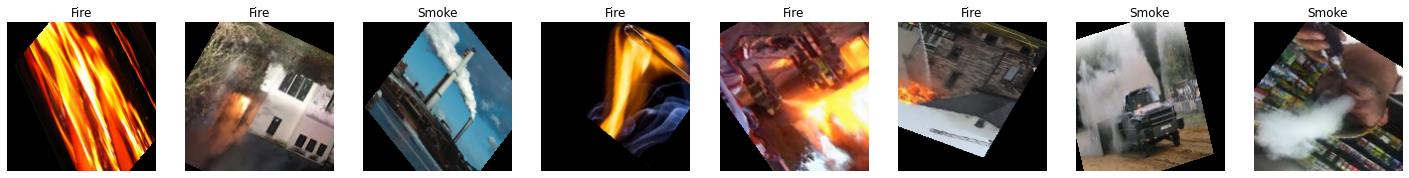

In [10]:
CLASS_NAMES = np.array(['Fire','Natural', 'Smoke',], dtype='<U10')

def show_batch(image_batch, label_batch):
  plt.figure(figsize=(25,3))
  for n in range(8):
      ax = plt.subplot(1,8,n+1)
      plt.imshow(image_batch[n])
      plt.title(CLASS_NAMES[label_batch[n]==1][0].title())
      plt.axis('off')
      
image_batch, label_batch = next(train_gen)
show_batch(image_batch, label_batch)

In [11]:
VGG_model = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=(img_h, img_w, 3))

58892288/58889256 [==============================] - 1s 0us/step


In [12]:

# The last 15 layers fine tune
for layer in VGG_model.layers[:-6]:
    layer.trainable = False

x = VGG_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Flatten()(x)
x = Dense(units=256, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(units=128, activation='relu')(x)
x = Dense(units=128, activation='relu')(x)
#x = Dropout(0.3)(x)
output  = Dense(units=3, activation='softmax')(x)
model = Model(VGG_model.input, output)


model.summary()


Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 150, 150, 3)]     0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 150, 150, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 150, 150, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 75, 75, 64)        0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 75, 75, 128)       73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 75, 75, 128)       147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 37, 37, 128)       0     

In [13]:
loss = tf.keras.losses.CategoricalCrossentropy()
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss=loss, metrics= ['accuracy'])

In [15]:
lrr = ReduceLROnPlateau(monitor='val_loss', 
                        patience=3, 
                        verbose=1, 
                        factor=0.4, 
                        min_lr=0.00001)

tensorbord = tf.keras.callbacks.TensorBoard(log_dir='./logs')

callbacks = [lrr,tensorbord]

STEP_SIZE_TRAIN=train_gen.n//train_gen.batch_size
STEP_SIZE_VALID=valid_gen.n//valid_gen.batch_size

transfer_learning_history = model.fit_generator(generator=train_gen,
                   steps_per_epoch=STEP_SIZE_TRAIN,
                   validation_data=valid_gen,
                   validation_steps=STEP_SIZE_VALID,
                   epochs=20,
                   callbacks=callbacks,
                 
                  
                    
)


  ...
    to  
  ['...']
  ...
    to  
  ['...']
Train for 222 steps, validate for 2 steps
Epoch 1/20
222/222 [==============================] - 816s 4s/step - loss: 0.6902 - accuracy: 0.6038 - val_loss: 0.3617 - val_accuracy: 0.7500
Epoch 2/20
222/222 [==============================] - 30s 136ms/step - loss: 0.3618 - accuracy: 0.8747 - val_loss: 0.1315 - val_accuracy: 0.9375
Epoch 3/20
222/222 [==============================] - 30s 135ms/step - loss: 0.2755 - accuracy: 0.8973 - val_loss: 0.3511 - val_accuracy: 0.8750
Epoch 4/20
222/222 [==============================] - 30s 135ms/step - loss: 0.2418 - accuracy: 0.9170 - val_loss: 0.1302 - val_accuracy: 1.0000
Epoch 5/20
222/222 [==============================] - 30s 134ms/step - loss: 0.2547 - accuracy: 0.9165 - val_loss: 0.1577 - val_accuracy: 0.9375
Epoch 6/20
222/222 [==============================] - 30s 134ms/step - loss: 0.2601 - accuracy: 0.9261 - val_loss: 0.2550 - val_accuracy: 0.9375
Epoch 7/20
221/222 [====================

### Visualization accuracy and loss 

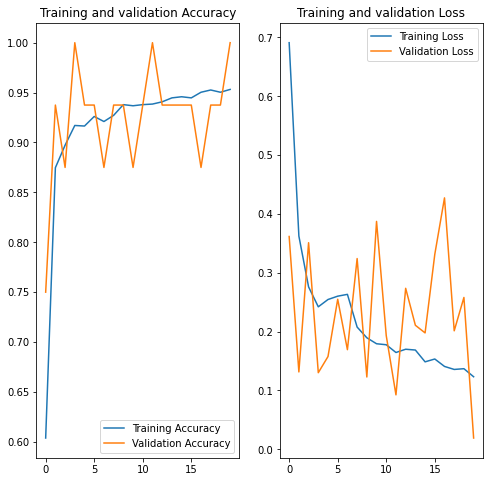

In [18]:

acc = transfer_learning_history.history['accuracy']
val_acc = transfer_learning_history.history['val_accuracy']
#test_acc = transfer_learning_history.history['test_accuracy']
loss = transfer_learning_history.history['loss']
val_loss = transfer_learning_history.history['val_loss']
#test_loss = transfer_learning_history.history['test_loss']
epochs_range = range(20)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
#plt.plot(epochs_range, test_acc, label='Test Accuracy')
plt.legend(loc='lower right')
plt.title('Training and validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
#plt.plot(epochs_range, test_loss, label='Test Loss')
plt.legend(loc='upper right')
plt.title('Training and validation Loss')
plt.show()

In [ ]:
%load_ext tensorboard
%tensorboard --logdir logs

### model evaluate with validation set

In [ ]:
#model.evaluate(valid_gen, steps=STEP_SIZE_VALID,verbose=1)

## model prediction with test data

In [19]:
STEP_SIZE_TEST=test_gen.n//test_gen.batch_size
test_gen.reset()
pred=model.predict(test_gen,
steps=STEP_SIZE_TEST,
verbose=1)

30/30 [==============================] - 199s 7s/step


In [22]:
predicted_class_indices=np.argmax(pred,axis=1)


### CSV file for kaggle submission

In [24]:
import pandas as pd
labels = train_gen.class_indices
labels = dict((v,k) for k,v in labels.items())
predictions = [k for k in predicted_class_indices]

filenames=test_gen.filenames
FN=[]
for i in filenames:
  f = i[5:]
  FN.append(f)
  

results=pd.DataFrame({"Id":FN,
                      "Category":predictions})
results.to_csv("result.csv",index=False)